# Supplementary Figures S17–S22: ARISTA

Supplementary Figures S21 and S22 are table-driven scientific redraws: the notebook clusters all 531 released ligand–receptor time courses, selects 25 representative pairs per cluster, and draws both figures from the tables calculated in this run. The formal PDFs remain separate references. Figures S17–S20 are included only as released reference pages because their complete layout inputs are not all distributed with the wheel.

The same redraw can be run after installation with `cytobridge figure arista-lr --output-dir outputs/arista_lr`.

## Setup

In [1]:
from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    calculate_arista_ligand_receptor_panels,
    export_arista_reference_pages,
    load_arista_figure_release,
    load_arista_supplementary_figures,
    plot_arista_ligand_receptor_figures,
    write_arista_ligand_receptor_tables,
    write_arista_source_index,
)

output_dir = Path("outputs") / "arista_supplementary_figures"
reference_dir = output_dir / "reference_pages"
output_dir.mkdir(parents=True, exist_ok=True)
data = load_arista_supplementary_figures()
data.figure_index[["figure", "topic"]]

,figure,topic
0,S17,Spatial interpolation
1,S18,Growth
2,S19,Lineage and composition
3,S20,Gene programs and GO enrichment
4,S21,Ligand-receptor clusters
5,S22,Ligand-receptor small multiples


## Calculate S21 and S22 from all released LR time courses

In [2]:
panels = calculate_arista_ligand_receptor_panels(data)
{
    "input_profiles": len(panels.assignments),
    "cluster_sizes": panels.prototypes.groupby("cluster")["n_pairs"].first().astype(int).to_dict(),
    "displayed_per_cluster": panels.display_roster.groupby("cluster").size().astype(int).to_dict(),
    "selected_k": int(panels.k_selection.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"]),
}

{'input_profiles': 531,
 'cluster_sizes': {1: 217, 2: 314},
 'displayed_per_cluster': {1: 25, 2: 25},
 'selected_k': 2}

## Draw S21 and S22 from the calculated tables

In [3]:
figures = plot_arista_ligand_receptor_figures(data, output_dir, panels)
tables = write_arista_ligand_receptor_tables(data, output_dir, panels)
{
    figure: {"pdf": paths[0].name, "png": paths[1].name}
    for figure, paths in figures.items()
}

{'S21': {'pdf': 'FigureS21_ARISTA_redrawn.pdf',
  'png': 'FigureS21_ARISTA_redrawn.png'},
 'S22': {'pdf': 'FigureS22_ARISTA_redrawn.pdf',
  'png': 'FigureS22_ARISTA_redrawn.png'}}

## Preview the table-driven scientific redraws

S21


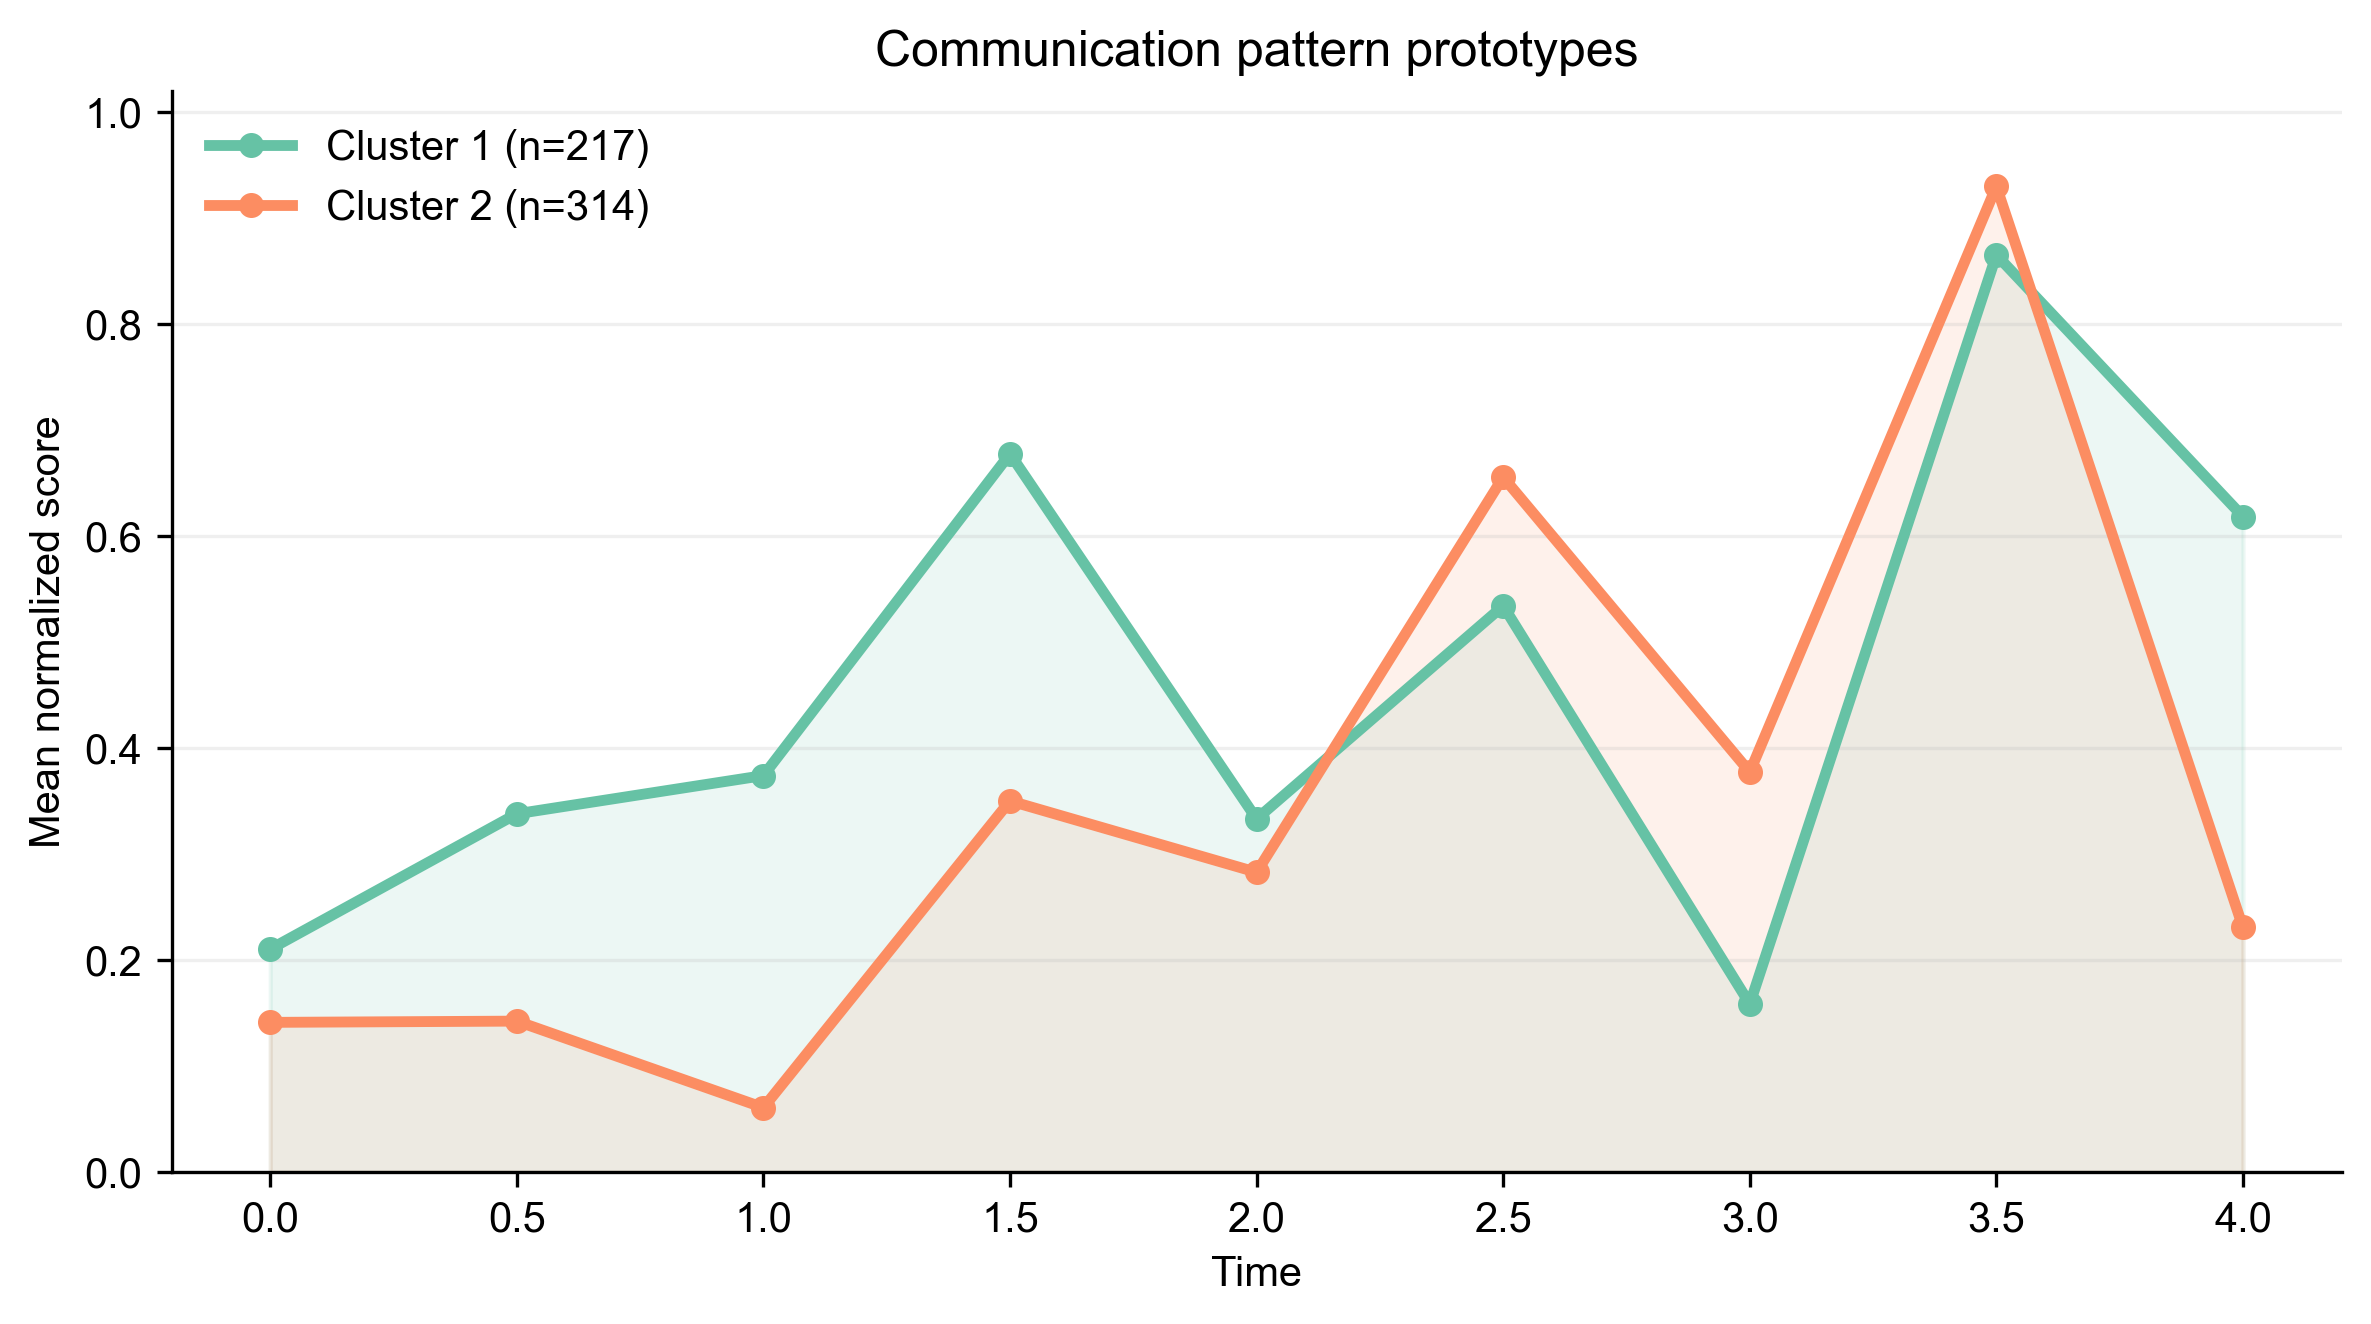

S22


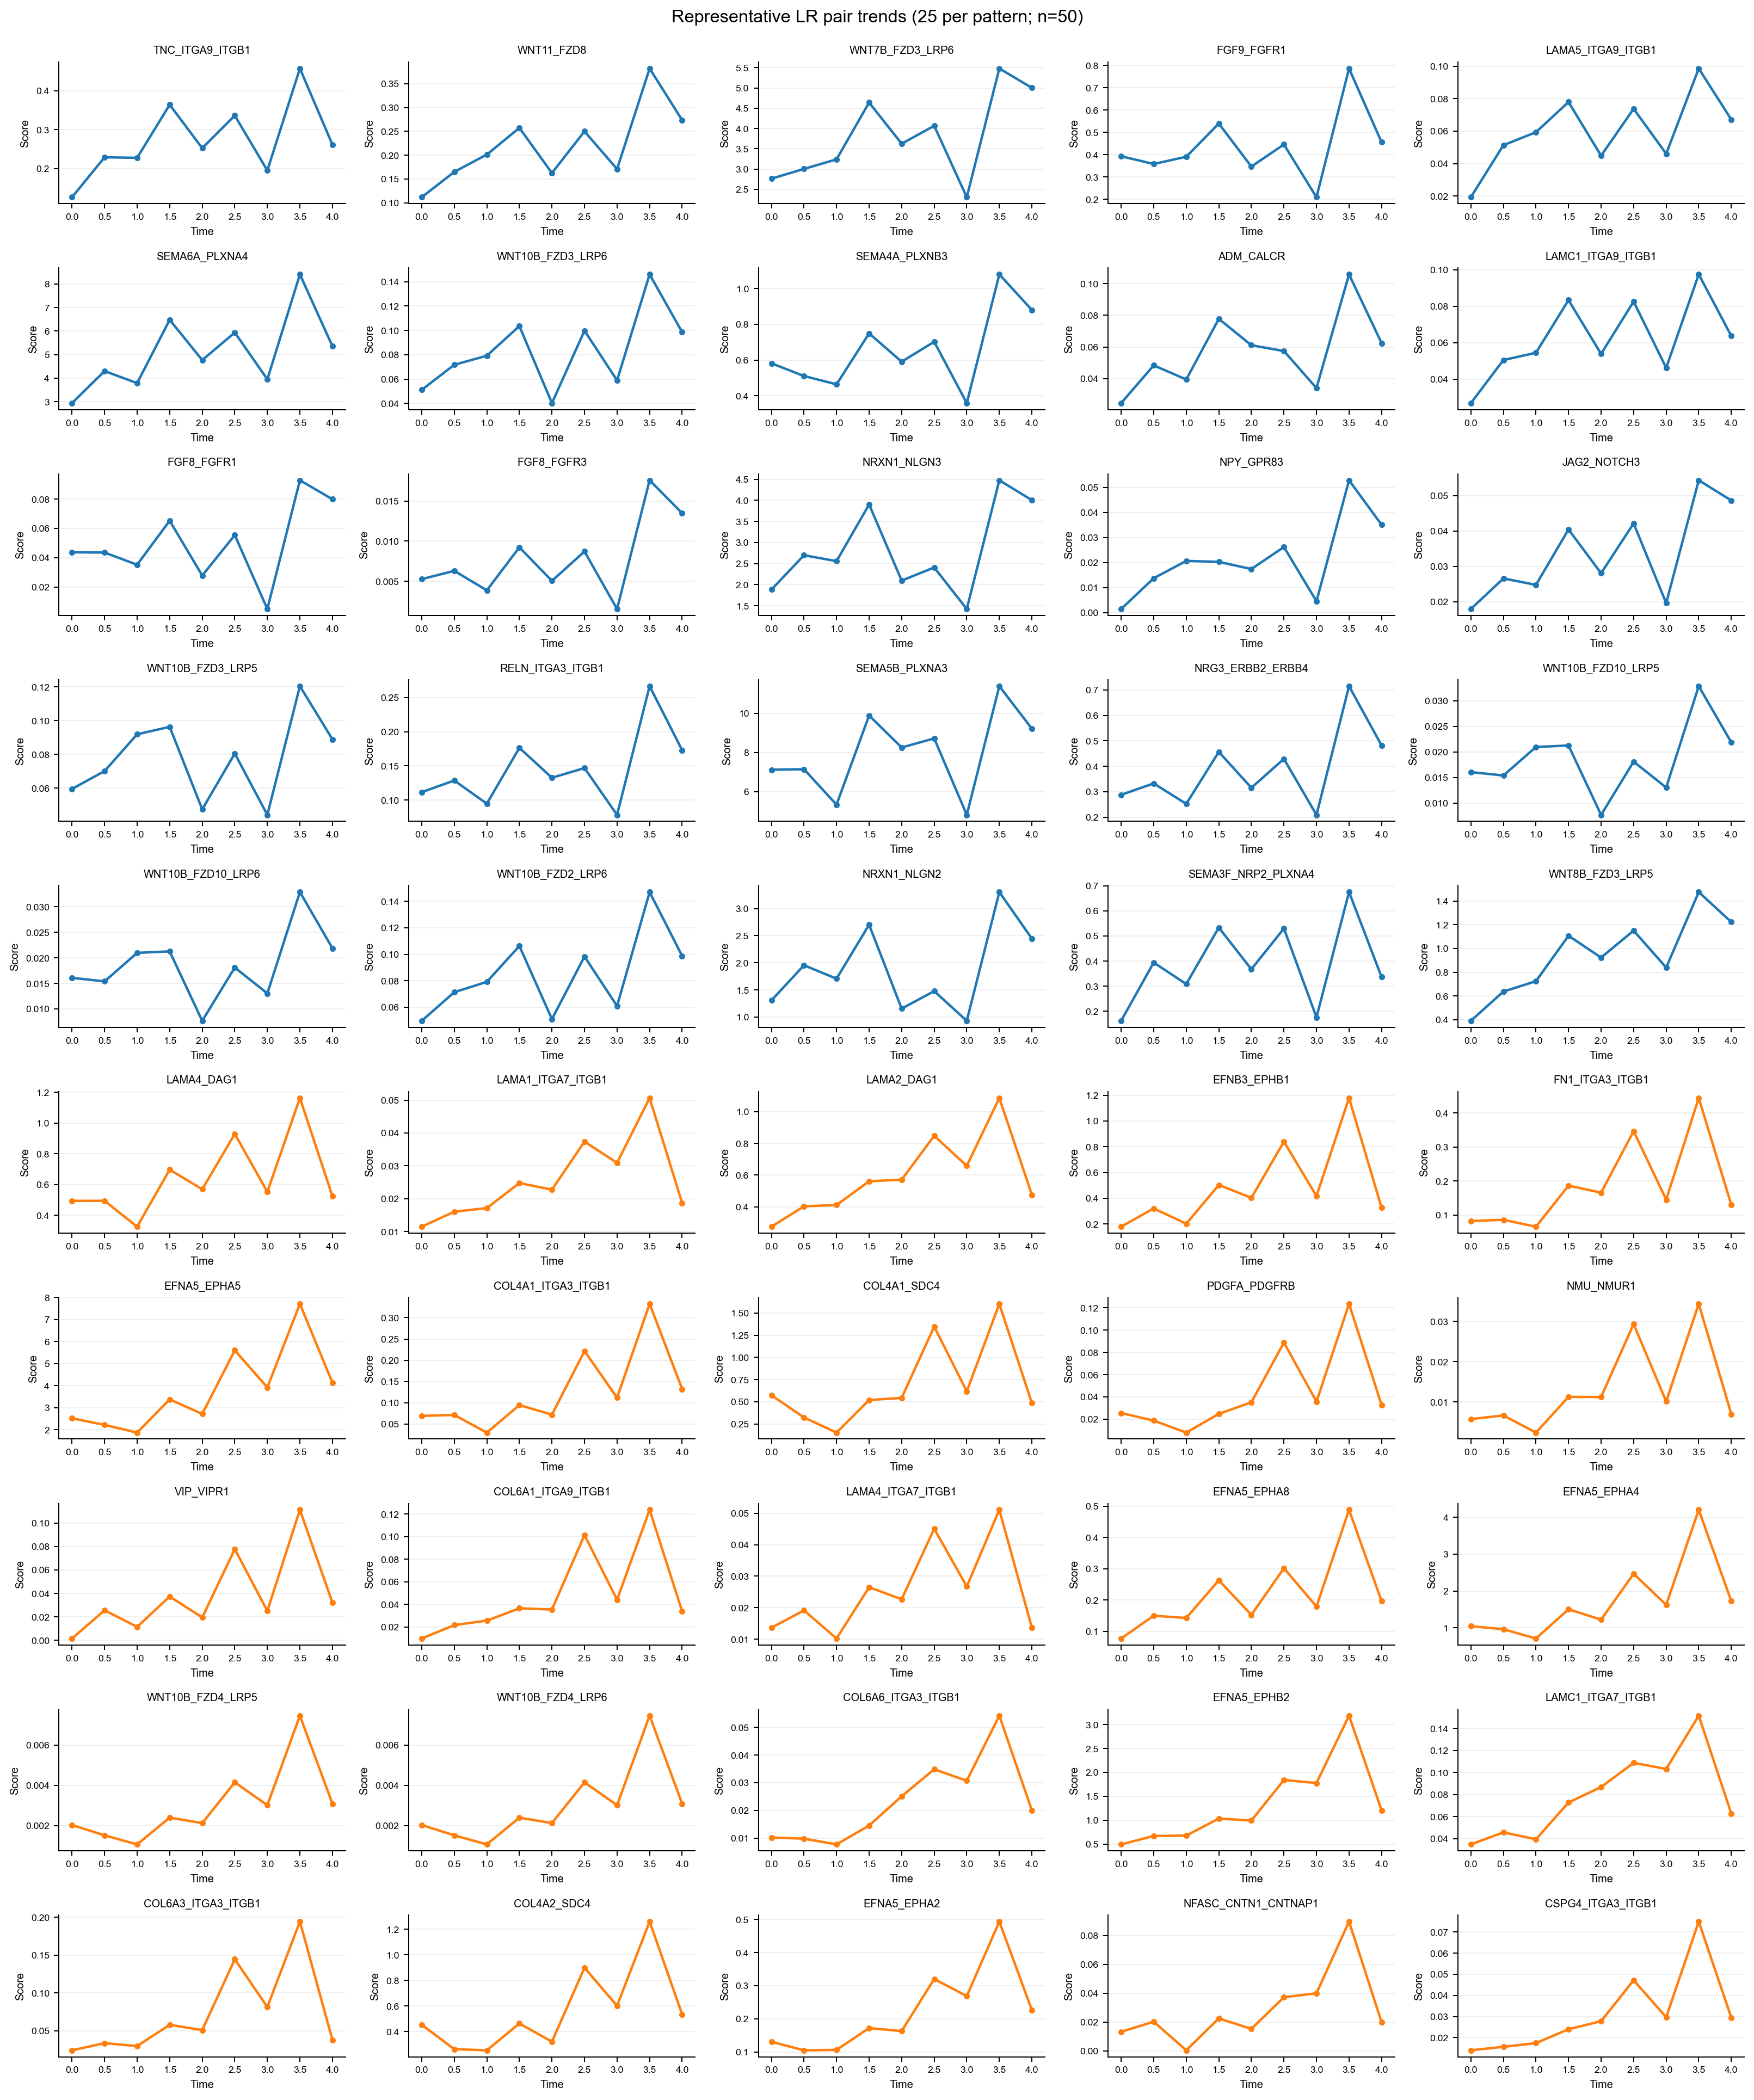

In [4]:
for figure, (_, png_path) in figures.items():
    print(figure)
    display(Image(filename=str(png_path), width=720))

## Released reference pages for S17–S20

In [5]:
reference_pages = export_arista_reference_pages(
    data,
    reference_dir,
    figures=("S17", "S18", "S19", "S20"),
)
{figure: paths[1].name for figure, paths in reference_pages.items()}

{'S17': 'FigureS17_ARISTA_interpolation.png',
 'S18': 'FigureS18_ARISTA_growth.png',
 'S19': 'FigureS19_ARISTA_lineage_composition.png',
 'S20': 'FigureS20_ARISTA_gene_programs_GO.png'}

## Formal sources and full-recalculation inputs

In [6]:
try:
    formal_release = load_arista_figure_release()
except FileNotFoundError:
    formal_release = None
    print("The formal page archive is available in a repository checkout; S21 and S22 above use package data only.")
else:
    formal_index_path = write_arista_source_index(formal_release, output_dir)
    display(formal_release.source_index[[
        "paper_location",
        "formal_pdf",
        "formal_svg",
        "formal_png",
        "vector_scope",
        "calculation_entrypoints",
        "canonical_scripts",
        "release_build_snapshot",
        "build_scope",
        "downstream_inputs",
        "input_scope",
        "checkpoint_inputs",
    ]])
data.full_recompute_inputs[["input_id", "stage", "figures"]]

,paper_location,formal_pdf,formal_svg,formal_png,vector_scope,calculation_entrypoints,canonical_scripts,release_build_snapshot,build_scope,downstream_inputs,input_scope,checkpoint_inputs
0,Supplementary Figure S17,S12_package_native_warpk1_oldstyle_v3_legacy_p...,S12_package_native_warpk1_oldstyle_v3_legacy_p...,S12_package_native_warpk1_oldstyle_v3_legacy_p...,full-page PDF and SVG,scripts/run_spatiotemporal_downstream.py;CytoB...,scripts/reviewer_arista_20260824/build_s12_pac...,S12_package_native_warpk1_oldstyle_v3_legacy_p...,release snapshot is the exact page builder; re...,main_run/downstream/slice_data/time_0.h5ad;mai...,release retains page slices and a derived tabl...,main_run/provenance/config.yaml;main_run/prove...
1,Supplementary Figure S18,S13_S14_package_native_oldstyle_v3_legacy_pale...,S13_S14_package_native_oldstyle_v3_legacy_pale...,S13_S14_package_native_oldstyle_v3_legacy_pale...,full-page PDF and SVG with nine embedded raste...,scripts/run_spatiotemporal_downstream.py;CytoB...,scripts/reviewer_arista_20260824/build_s13_s14...,S13_S14_package_native_oldstyle_v3_legacy_pale...,release snapshot is the exact page builder; re...,main_run/downstream/growth/growth_by_cell.csv;...,release retains growth and display tables; spa...,main_run/provenance/config.yaml;main_run/prove...
2,Supplementary Figure S19,S13_S14_package_native_oldstyle_v3_legacy_pale...,S13_S14_package_native_oldstyle_v3_legacy_pale...,S13_S14_package_native_oldstyle_v3_legacy_pale...,full-page PDF and SVG,scripts/run_spatiotemporal_downstream.py;CytoB...,scripts/reviewer_arista_20260824/build_s13_s14...,S13_S14_package_native_oldstyle_v3_legacy_pale...,release snapshot is the exact page builder; re...,S13_S14_package_native_oldstyle_v3_legacy_pale...,release retains derived fixed-particle tables;...,main_run/provenance/config.yaml;main_run/prove...
3,Supplementary Figure S20,S15_S17_package_native_strict_oldstyle_v1/figu...,S15_S17_package_native_strict_oldstyle_v1/figu...,S15_S17_package_native_strict_oldstyle_v1/figu...,raster composite PDF; four retained panel SVGs...,scripts/run_spatiotemporal_downstream.py;CytoB...,scripts/reviewer_arista_20260824/build_s15_s17...,,repository builder; no duplicate builder in th...,S15_S17_package_native_strict_oldstyle_v1/prov...,release retains the builder source snapshots,main_run/provenance/config.yaml;main_run/prove...
4,Supplementary Figure S21,S16_package_native_kmeans_oldstyle_v1_finalqa/...,S16_package_native_kmeans_oldstyle_v1_finalqa/...,S16_package_native_kmeans_oldstyle_v1_finalqa/...,full-page PDF and SVG,scripts/run_spatiotemporal_downstream.py;CytoB...,scripts/reviewer_arista_20260824/recluster_ari...,S16_package_native_kmeans_oldstyle_v1_finalqa/...,release snapshot is the exact page builder,S15_S17_package_native_strict_oldstyle_v1/prov...,"release retains the strict pair scores, correc...",main_run/provenance/config.yaml;main_run/prove...
5,Supplementary Figure S22,S17_package_native_balanced25_oldstyle_v1/figu...,S17_package_native_balanced25_oldstyle_v1/figu...,S17_package_native_balanced25_oldstyle_v1/figu...,full-page PDF and SVG,scripts/run_spatiotemporal_downstream.py;CytoB...,scripts/reviewer_arista_20260824/recluster_ari...,S17_package_native_balanced25_oldstyle_v1/buil...,release snapshot is the exact page builder,S15_S17_package_native_strict_oldstyle_v1/prov...,"release retains the corrected assignments, nor...",main_run/provenance/config.yaml;main_run/prove...


,input_id,stage,figures
0,raw_h5ad,download,S17;S18;S19;S20;S21;S22
1,aligned_h5ad,generated,S17;S18;S19;S20;S21;S22
2,model_dir,generated,S17;S18;S19;S20;S21;S22
3,slice_dir,generated,S17;S18
4,growth_by_cell,generated,S18
5,fixed_particle_composition,generated,S19
6,gene_mean_expression,generated,S20
7,gene_reconstruction_diagnostics,generated,S20
8,go_biological_process_gmt,download,S20
9,lr_pair_timecourse,generated,S21;S22
